In [1]:
%matplotlib widget

# ROS2 Libraries
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import PointCloud2
from geometry_msgs.msg import TransformStamped, PointStamped, PoseStamped

# dVRK
import dvrk
import crtk

# Python Libraries
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Custom Libraries 
from utils import tf_utils, pcl_utils, misc_utils, ik_utils, dvrk_utils, ros2_utils

In [2]:
rclpy.init(args=None)

In [3]:
class SUB_ROS_MSGS(Node):
    def __init__(self, params):
        super().__init__(params["node_name"])
        self.params        = params
        self.ctrd_3d       = None
        self.bnd_3d        = None
        self.cnt_3d        = None
        self.g_fbf         = None
        self.g_fbfjaw      = None
        self.grasp_dir     = None
        self.jp_align      = None
        self.jp_grasp      = None
        self.jp_pull       = None
        self.jp_release    = None
        self.tissue_norm   = None
        self.custom_arm_cp = None
        self.custom_local_arm_cp = None
        self.custom_jaw_cp = None
        self.custom_local_jaw_cp = None
        self.arm_cp_tn = "/{}/custom/setpoint_cp".format(params['arm_name'])
        self.arm_local_cp_tn = "/{}/custom/local/setpoint_cp".format(params['arm_name'])
        if "PSM" in params['arm_name']:
            self.jaw_cp_tn = "/{}/custom/jaw/setpoint_cp".format(params['arm_name'])
            self.jaw_local_cp_tn = "/{}/custom/local/jaw/setpoint_cp".format(params['arm_name'])

        self.g_ecmopencv_ecmdvrk = self.load_tf(params["tf_path"])
        self.align_dist     = params["align_dist"]
        self.grasp_offset   = params["grasp_offset"]
        self.align_ratio    = params["align_ratio"]
        self.min_pull_dist  = params["min_pull_dist"]
        self.jaw_open_angle = params["jaw_open_angle"]
        self.add_subs()

    def custom_arm_cp_callback(self, msg):
        ros2_utils.loginfo(self, "arm_cp", True)
        self.custom_arm_cp = tf_utils.posestamped2g(msg)

    def custom_local_arm_cp_callback(self, msg):
        ros2_utils.loginfo(self, "local_arm_cp", True)
        self.custom_local_arm_cp = tf_utils.posestamped2g(msg)

    def custom_jaw_cp_callback(self, msg):
        ros2_utils.loginfo(self, "jaw_cp", True)
        self.custom_jaw_cp = tf_utils.posestamped2g(msg)

    def custom_local_jaw_cp_callback(self, msg):
        ros2_utils.loginfo(self, "local_jaw_cp", True)
        self.custom_local_jaw_cp = tf_utils.posestamped2g(msg)

    def cnt_3d_cb(self, cnt_3d_msg):
        ros2_utils.loginfo(self, "cnt_3d", True)
        self.cnt_3d = pcl_utils.pcl2nparray(cnt_3d_msg)

    def bnd_3d_cb(self, bnd_3d_msg):
        ros2_utils.loginfo(self, "bnd_3d", True)
        self.bnd_3d = pcl_utils.pcl2nparray(bnd_3d_msg)

    def ctrd_3d_cb(self, ctrd_3d_msg):
        ros2_utils.loginfo(self, "ctrd_3d", True)
        self.ctrd_3d = tf_utils.ptstamped2pt3d(ctrd_3d_msg)

    def grasp_3d_cb(self, grasp_3d_msg):
        ros2_utils.loginfo(self, "grasp_3d", True)
        self.grasp_3d = tf_utils.ptstamped2pt3d(grasp_3d_msg)

    def fbf_kpt_cb(self, fbf_cp_msg):
        ros2_utils.loginfo(self, "fbf_cp", True)
        self.g_fbf = tf_utils.tfstamped2g(fbf_cp_msg)

    def fbf_jaw_kpt_cb(self, fbf_jaw_cp_msg):
        ros2_utils.loginfo(self, "fbf_jaw_cp", True)
        self.g_fbfjaw = tf_utils.tfstamped2g(fbf_jaw_cp_msg)

    def add_subs(self):
        # Create a subscriber for the arm's cartesian position
        self.custom_arm_cp_sub = self.create_subscription(
            PoseStamped,
            self.arm_cp_tn,
            self.custom_arm_cp_callback,
            self.params['queue_size']
        )
        # Create a subscriber for the arm's local cartesian position
        self.custom_arm_local_cp_sub = self.create_subscription(
            PoseStamped,
            self.arm_local_cp_tn,
            self.custom_local_arm_cp_callback,
            self.params['queue_size']
        )
        # Create a subscriber for the jaw's cartesian position (if applicable)
        if hasattr(self, 'jaw_cp_tn'):
            self.custom_jaw_cp_sub = self.create_subscription(
                PoseStamped,
                self.jaw_cp_tn,
                self.custom_jaw_cp_callback,
                self.params['queue_size']
            )
        # Create a subscriber for the jaw's local cartesian position (if applicable)
        if hasattr(self, 'jaw_local_cp_tn'):
            self.custom_jaw_local_cp_sub = self.create_subscription(
                PoseStamped,
                self.jaw_local_cp_tn,
                self.custom_local_jaw_cp_callback,
                self.params['queue_size']
            )
        self.cnt_sub = self.create_subscription(
            PointCloud2,
            self.params['cnt_topic'],
            self.cnt_3d_cb,
            self.params['queue_size']
        )
        self.bnd_sub = self.create_subscription(
            PointCloud2,
            self.params['bnd_topic'],
            self.bnd_3d_cb,
            self.params['queue_size']
        )
        self.ctrd_sub = self.create_subscription(
            PointStamped,
            self.params['ctrd_topic'],
            self.ctrd_3d_cb,
            self.params['queue_size']
        )
        self.grasp_sub = self.create_subscription(
            PointStamped,
            self.params['grasp_topic'],
            self.grasp_3d_cb,
            self.params['queue_size']
        )
        self.fbf_ktp_sub = self.create_subscription(
            TransformStamped,
            self.params['fbf_kpt_topic'],
            self.fbf_kpt_cb,
            self.params['queue_size']
        )

        self.fbf_jaw_kpt_sub = self.create_subscription(
            TransformStamped,
            self.params['fbf_jaw_kpt_topic'],
            self.fbf_jaw_kpt_cb,
            self.params['queue_size']
        )

    def load_tf(self, tf_path):
        tf_data = tf_utils.load_tf_data(tf_path)
        g_ecmdvrk_ecmopencv = np.array(tf_data["g_ecmdvrk_ecmopencv"])
        return tf_utils.ginv(g_ecmdvrk_ecmopencv)

    def get_tf(self, dir_vec, des_loc):
        z_tf = dir_vec
        y_tf = misc_utils.unit_vector(np.cross(dir_vec, np.array([0, 0, -1])))
        x_tf = misc_utils.unit_vector(np.cross(y_tf, dir_vec))
        R_tf = np.vstack((x_tf, y_tf, z_tf)).T
        return tf_utils.gen_g(R_tf, des_loc)

    def armtip_offset(self, g_ecmtip_armtip, g_armtip_dt2):
        g_ecmopencv_armtip = self.g_ecmopencv_ecmdvrk.dot(g_ecmtip_armtip)
        return g_armtip_dt2[:3,3] - g_ecmopencv_armtip[:3,3]

In [4]:
home_dir = os.path.expanduser('~')
params = {
    'node_name'         : 'grasp_gallb',
    'arm_name'          : 'PSM2',
    'expected_interval' : 0.01,
    'queue_size'        : 5,
    'slop'              : 0.5,
    'cnt_topic'         : '/yolo/seg/gallb/cnts',
    'bnd_topic'         : '/yolo/seg/gallb/bnd',
    'ctrd_topic'        : '/yolo/seg/gallb/ctrd',
    'grasp_topic'       : '/yolo/seg/gallb/grasp',
    'key_topic'         : '/keyboard/grasp',
    'fbf_kpt_topic'     : '/yolo/kpt/fbf/psm_cp',
    'fbf_jaw_kpt_topic' : '/yolo/kpt/fbf/psmjaw_cp',
    'tf_path'           : os.path.join(home_dir, 'aruco_data/base_tfs.yaml'),
    'calib_fn'          : os.path.join(home_dir, 'aruco_data/psm2_calib_results_final_new_v2.mat'),
    'Tweight'           : 1.0,
    'Rweight'           : 0.1,
    'align_dist'        : 0.01,
    'min_pull_dist'     : 0.01,
    'jaw_open_angle'    : 80,
    'grasp_offset'      : 0.005,
    'window_size'       : 15,
    'window_thr'        : 3e-4,
    'Joffsets'          : [60, 60, 5, 100, 60, 90],
    'align_ratio'       : [0.7, 0.3],
}

In [5]:
app = SUB_ROS_MSGS(params)

In [6]:
rclpy.spin(app)

[INFO] [1739487660.304481231] [grasp_gallb]: arm_cp


KeyboardInterrupt: 

# fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(app.grasp_3d[0], app.grasp_3d[1], app.grasp_3d[2], c='g', marker='o')
ax.scatter(app.bnd_3d[:,0], app.bnd_3d[:,1], app.bnd_3d[:,2], c='r', marker='o')

In [8]:
pca_comps = misc_utils.cnt_axes_3d(app.bnd_3d)
tissue_norm = misc_utils.unit_vector(app.bnd_3d.mean(axis=0) - app.grasp_3d)
pca_x = np.argmax([np.dot(np.array([1,0,0]), pca_comp) for pca_comp in pca_comps])
grasp_dir = misc_utils.unit_vector(pca_x*app.align_ratio[0] + tissue_norm*app.align_ratio[1])

In [9]:
grasp_dir

array([0.61082096, 0.5195547 , 0.59746185])

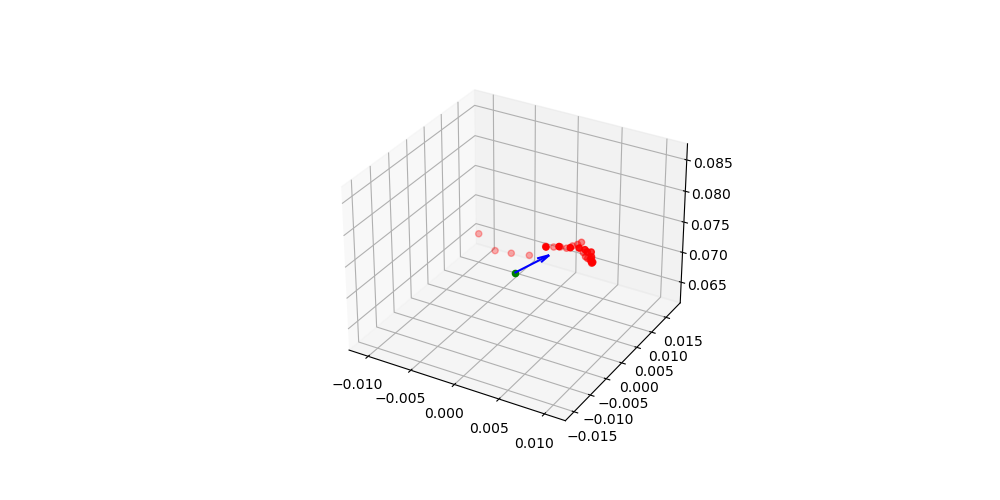

In [10]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(app.grasp_3d[0], app.grasp_3d[1], app.grasp_3d[2], c='g', marker='o')
ax.scatter(app.bnd_3d[:,0], app.bnd_3d[:,1], app.bnd_3d[:,2], c='r', marker='o')
ax.quiver(*app.grasp_3d, *grasp_dir*0.005, color='b')

In [13]:
g_ecmtip_armtip = app.custom_arm_cp
g_ecmopencv_armtip = app.g_ecmopencv_ecmdvrk.dot(g_ecmtip_armtip)
g_ecmopencv_armtip

array([[ 0.58006515,  0.44618634,  0.68149994, -0.00837517],
       [-0.0201005 ,  0.8442233 , -0.53561458, -0.00994759],
       [-0.81432204,  0.29699287,  0.49867309,  0.06395058],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [15]:
app.g_fbf

array([[ 0.58006515,  0.44618634,  0.68149994, -0.0185413 ],
       [-0.0201005 ,  0.8442233 , -0.53561458, -0.00925772],
       [-0.81432204,  0.29699287,  0.49867309,  0.06233871],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [16]:
g_ecmtip_armtip

array([[-0.58791491, -0.48465584, -0.64766101,  0.00757414],
       [ 0.07799693, -0.8308792 ,  0.55095937,  0.01045851],
       [-0.80515374,  0.27340166,  0.52628794,  0.07364692],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])